# **Caracterización de los casos de Dengue**

-----------------------

In [1]:
# [Configuración] Importar librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches

import seaborn as sns

import geopandas as gpd

In [2]:
# [Datos]
data_atl= pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/main/DATA/registros_atlantico.csv", encoding='latin-1')
data_col = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/main/DATA/registros_colombia.csv", encoding='latin-1')

pob_atl = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/main/DATA/poblacion_depart.csv", encoding='latin-1')
pob_col = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/main/DATA/poblacion_nacional.csv", encoding='latin-1')

In [3]:
mapa_atl = gpd.read_file("./MAPAS/MAPAS_MUN/MGN_ADM_MPIO_GRAFICO.shp")
mapa_col = gpd.read_file("./MAPAS/MAPAS_DPTO/MGN_ADM_DPTO_POLITICO.shp")
mapa_atl = mapa_atl.rename(columns={'mpio_cnmbr': 'municipio'})
mapa_atl = mapa_atl[mapa_atl['dpto_cnmbr'] == 'ATLÁNTICO']
mapa_col = mapa_col.rename(columns={'dpto_cnmbr': 'departamento'})

In [4]:
display(data_col.info())
display(data_atl.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491869 entries, 0 to 491868
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   sexo            491869 non-null  object
 1   edad_años       491869 non-null  int64 
 2   ciclo_vital     491869 non-null  object
 3   grupo_etnico    491869 non-null  object
 4   regimen_salud   491869 non-null  object
 5   evento          491869 non-null  object
 6   tipo_caso       491869 non-null  object
 7   hospitalizado   491869 non-null  object
 8   desenlace       491869 non-null  object
 9   año             491869 non-null  int64 
 10  semana          491869 non-null  int64 
 11  periodo         491869 non-null  int64 
 12  fecha_ini_sint  491869 non-null  object
 13  fecha_consulta  491868 non-null  object
 14  fecha_hospital  238132 non-null  object
 15  fecha_notific   491869 non-null  object
 16  departamento    491869 non-null  object
 17  municipio       491869 non-nu

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14522 entries, 0 to 14521
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sexo            14522 non-null  object
 1   edad_años       14522 non-null  int64 
 2   ciclo_vital     14522 non-null  object
 3   grupo_etnico    14522 non-null  object
 4   regimen_salud   14522 non-null  object
 5   evento          14522 non-null  object
 6   tipo_caso       14522 non-null  object
 7   hospitalizado   14522 non-null  object
 8   desenlace       14522 non-null  object
 9   año             14522 non-null  int64 
 10  semana          14522 non-null  int64 
 11  periodo         14522 non-null  int64 
 12  fecha_ini_sint  14522 non-null  object
 13  fecha_consulta  14522 non-null  object
 14  fecha_hospital  14522 non-null  object
 15  fecha_notific   14522 non-null  object
 16  departamento    14522 non-null  object
 17  municipio       14522 non-null  object
 18  subreg

None

> Para los años de estudio considerados, se tienen `491,869` registros de dengue reportados en todo el territorio nacional. Además de los `14,522` registros de casos de dengue del Atlántico.

In [4]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, df, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(3)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(3)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(3)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    display(tabla_completa)
    print("\n-----------------------------------")

## **Colombia**

In [5]:
# Variables demograficas
print("DEMOGRAFÍA DE LOS REGISTROS")
describir_categorica(data_col["ciclo_vital"], data_col)
describir_categorica(data_col["sexo"], data_col)
describir_categorica(data_col["grupo_etnico"], data_col)
describir_categorica(data_col["regimen_salud"], data_col)

DEMOGRAFÍA DE LOS REGISTROS

📌 Variable: ciclo_vital


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
ciclo_vital,,,,,,
Adulto,170458,0.347,168616,1842,0.989,0.011
Infancia mayor,119843,0.244,118063,1780,0.985,0.015
Adolescencia,97515,0.198,96003,1512,0.984,0.016
Infancia menor,75388,0.153,74319,1069,0.986,0.014
Adulto mayor,24716,0.050,24323,393,0.984,0.016
Desconocido,3949,0.008,3815,134,0.966,0.034



-----------------------------------

📌 Variable: sexo


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
sexo,,,,,,
Masculino,257938,0.524,254516,3422,0.987,0.013
Femenino,233931,0.476,230623,3308,0.986,0.014



-----------------------------------

📌 Variable: grupo_etnico


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
grupo_etnico,,,,,,
Otro,464563,0.944,458161,6402,0.986,0.014
Afrocolombiano,18927,0.038,18724,203,0.989,0.011
Indígena,7277,0.015,7170,107,0.985,0.015
Rom,1102,0.002,1084,18,0.984,0.016



-----------------------------------

📌 Variable: regimen_salud


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
regimen_salud,,,,,,
Subsidiado,256977,0.522,252934,4043,0.984,0.016
Contributivo,193475,0.393,191349,2126,0.989,0.011
Excepción,23504,0.048,23214,290,0.988,0.012
No asegurado,12423,0.025,12220,203,0.984,0.016
Indeterminado,4301,0.009,4249,52,0.988,0.012
Especial,1189,0.002,1173,16,0.987,0.013



-----------------------------------


Durante el periodo comprendido entre 2018 y 2023, la mayor proporción de casos registrados de dengue en Colombia correspondió a personas en edad _adulta_ (18–59 años), quienes representaron el 32,6% del total. En segundo lugar se ubicaron los pacientes en _infancia menor_ (1–5 años) con un 24,4%, seguidos por aquellos en _adolescencia_ (12–17 años) con un 21,9%. En contraste, los casos en personas mayores de 60 años (_adulto mayor_) constituyeron únicamente el 5% del total de registros. Finalmente, se observó que el 0,8% de los casos correspondieron a pacientes con edad no especificada.

Los casos de dengue fueron ligeramente más frecuentes en pacientes _masculinos_ (52,4%) que en _femenino_ (47,6%). Solo una proporción del 5,5% de los pacientes pertenece a un grupo étnico específico (_afrocolombiano, indígena o ROM_). En cuanto al régimen de salud, la mitad de los casos (52,2%) corresponde al régimen _subsidiado_, mientras que el 39,3% está afiliado al régimen _contributivo_, y el 8,4% restante a otros tipos de afiliación.

In [6]:
# Variables de evento 
print("EVENTO DEL DENGUE EN LOS REGISTROS")
describir_categorica(data_col["evento"], data_col)
describir_categorica(data_col["tipo_caso"], data_col)
describir_categorica(data_col["hospitalizado"], data_col)
describir_categorica(data_col["desenlace"], data_col)

EVENTO DEL DENGUE EN LOS REGISTROS

📌 Variable: evento


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
evento,,,,,,
Clasico,485139,0.986,485139,0,1.0,0.0
Grave,6730,0.014,0,6730,0.0,1.0



-----------------------------------

📌 Variable: tipo_caso


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
tipo_caso,,,,,,
Probable,345462,0.702,341299,4163,0.988,0.012
Conf. por laboratorio,143442,0.292,140875,2567,0.982,0.018
Conf. por nexo,2965,0.006,2965,0,1.000,0.000



-----------------------------------

📌 Variable: hospitalizado


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
hospitalizado,,,,,,
No,253737,0.516,253499,238,0.999,0.001
Si,238132,0.484,231640,6492,0.973,0.027



-----------------------------------

📌 Variable: desenlace


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
desenlace,,,,,,
Vivo,491711,1.0,485138,6573,0.987,0.013
Fallecido,158,0.0,1,157,0.006,0.994



-----------------------------------


El evento de dengue registrado se divide en casos de dengue clásico (485.139) y dengue grave (6.730). Del total, el 70,2% de los casos fueron clasificados como probables, mientras que el resto correspondió a casos confirmados por laboratorio o por nexo epidemiológico. Aproximadamente el 48,4% de los pacientes requirió hospitalización debido a la afectación del virus, registrándose 158 muertes asociadas a dengue grave.

In [7]:
# Variables espaciales
print("OCURRENCIA ESPACIAL DE LOS CASOS")
describir_categorica(data_col["area"], data_col)

OCURRENCIA ESPACIAL DE LOS CASOS

📌 Variable: area


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
area,,,,,,
Cabecera municipal,405657,0.825,400114,5543,0.986,0.014
Rural disperso,50607,0.103,49935,672,0.987,0.013
Centro poblado,35605,0.072,35090,515,0.986,0.014



-----------------------------------


In [10]:
# Agrupar casos totales por departamento
tabla_dep = data_col.groupby("departamento").size().reset_index(name="casos")
pob_col = pob_col.rename(columns={'DEPARTAMENTO': 'departamento'})
pob_total = pob_col[['departamento', 'TOTAL']].copy()
pob_total = pob_total.rename(columns={'TOTAL': 'poblacion'})
tabla_dep = tabla_dep.merge(pob_total, on='departamento', how='left')
total_casos = tabla_dep['casos'].sum()
tabla_dep['proporcion'] = round(tabla_dep['casos'] / total_casos, 3)
tabla_dep['incidencia'] = round((tabla_dep['casos'] / tabla_dep['poblacion']) * 100000, 2)
tabla_dep = tabla_dep[['departamento', 'casos', 'proporcion', 'incidencia']]
display(tabla_dep)

,departamento,casos,proporcion,incidencia
0,AMAZONAS,3765,0.008,784.10
1,ANTIOQUIA,19548,0.040,49.00
2,ARAUCA,5759,0.012,354.86
3,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",537,0.001,143.79
4,ATLÁNTICO,33715,0.069,208.65
5,BOLÍVAR,33468,0.068,259.17
6,BOYACÁ,2252,0.005,30.01
7,CALDAS,1418,0.003,23.03
8,CAQUETÁ,6543,0.013,264.40
9,CASANARE,14422,0.029,542.38


In [15]:
# Unir la tabla de incidencia con el mapa por nombre de departamento
mapa_col = mapa_col.merge(tabla_dep, on='departamento', how='left')

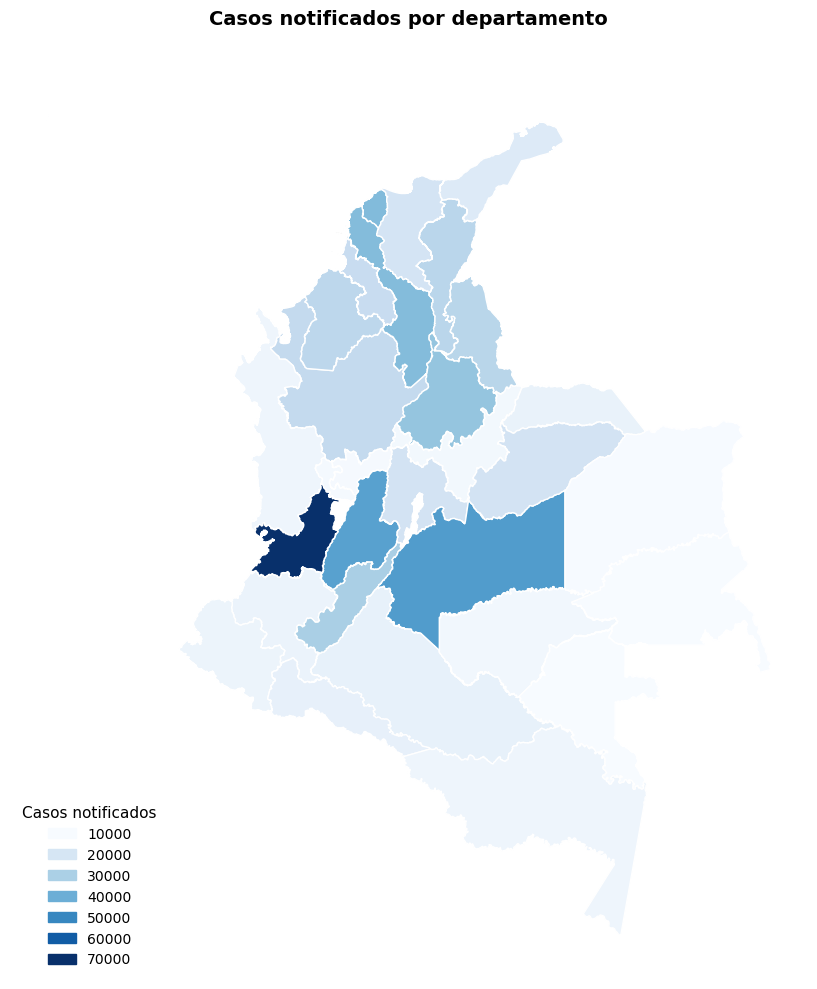

In [24]:
bins = [10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000]
cmap = plt.cm.Blues
norm = colors.BoundaryNorm(bins, cmap.N)

# Configurar el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
mapa_col.plot(column='casos',
              cmap=cmap,
              linewidth=1,
              edgecolor='1',
              legend_kwds={'label': "Casos notificados"},
              label=True,
              ax=ax)
# Crear leyenda personalizada con parches
legend_labels = [f"{bins[i]}" for i in range(len(bins)-1)]
legend_colors = [cmap(norm(bins[i])) for i in range(len(bins)-1)]
patches = [mpatches.Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Añadir leyenda al gráfico
ax.legend(handles=patches,
          title="Casos notificados",
          loc='lower left',
          frameon=False,
          fontsize=10,
          title_fontsize=11)
# Estética del mapa
ax.set_title("Casos notificados por departamento", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

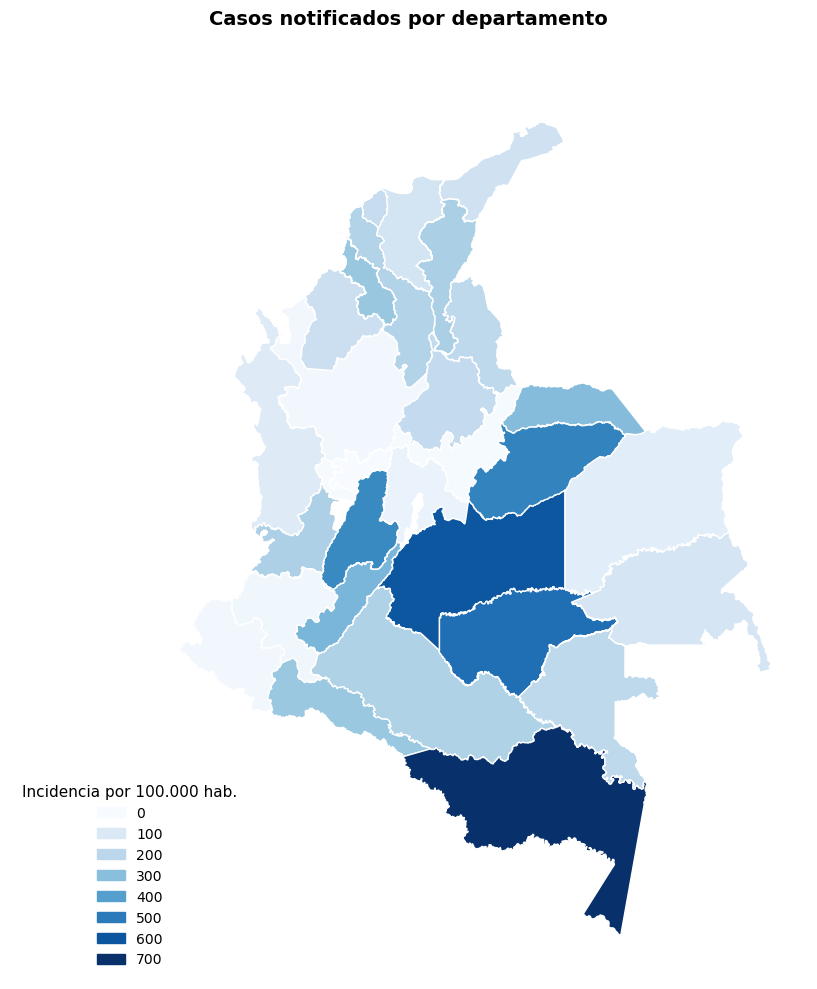

In [27]:
bins = [0, 100, 200, 300, 400, 500, 600, 700, 800]
cmap = plt.cm.Blues
norm = colors.BoundaryNorm(bins, cmap.N)

# Configurar el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
mapa_col.plot(column='incidencia',
              cmap=cmap,
              linewidth=1,
              edgecolor='1',
              legend_kwds={'label': "Incidencia por 100.000 habitantes"},
              label=True,
              ax=ax)
# Crear leyenda personalizada con parches
legend_labels = [f"{bins[i]}" for i in range(len(bins)-1)]
legend_colors = [cmap(norm(bins[i])) for i in range(len(bins)-1)]
patches = [mpatches.Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Añadir leyenda al gráfico
ax.legend(handles=patches,
          title="Incidencia por 100.000 hab.",
          loc='lower left',
          frameon=False,
          fontsize=10,
          title_fontsize=11)

# Estética del mapa
ax.set_title("Casos notificados por departamento", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

La distribución espacial de los casos mostró que la mayor concentración de registros se presentó en el departamento del Valle del Cauca, que aportó el 15.3% del total nacional. Posteriormente, la carga de enfermedad se concentró en otros departamentos de alta notificación: Meta (8.9%) y Tolima (8.6%) conformaron un bloque con más de 40.000 registros. A estos les siguió el conjunto de Atlántico, Bolívar y Santander, con más de 30.000 notificaciones cada uno. En contraste, departamentos de baja densidad poblacional —como San Andrés, Providencia y Santa Catalina, Guainía, Vaupés y Vichada— reportaron menos de 1.000 casos durante el periodo analizado.

Sin embargo, al examinar el riesgo poblacional mediante la incidencia, emergió un patrón diferente. El departamento del Amazonas registró la mayor incidencia del país, con 784 casos por cada 100.000 habitantes. Le siguieron Meta, Guaviare, Casanare y Tolima, territorios donde la intensidad de la transmisión fue elevada, superando los 500 casos por cada 100.000 habitantes.

OCURRENCIA TEMPORAL DE LOS CASOS


,count
año,
2018,44171
2019,124989
2020,77281
2021,50265
2022,67031
2023,128132


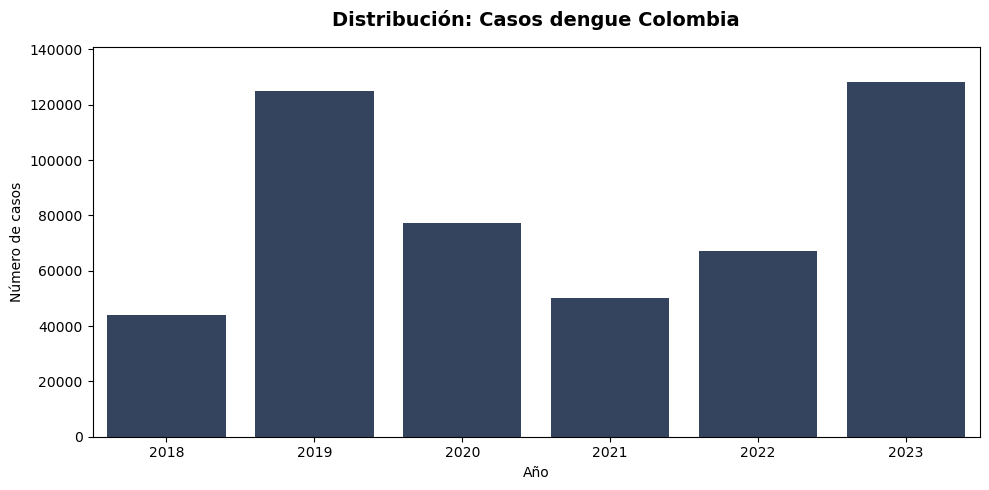

In [9]:
# Variables temporales
print("OCURRENCIA TEMPORAL DE LOS CASOS")
conteo_por_año = data_col['año'].value_counts(sort=False).sort_index()
display(conteo_por_año.to_frame())

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución: Casos dengue Colombia', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La ocurrencia temporal de los casos de dengue, muestra un patron de fluctuaciones.  En 2019 y 2023 se registraron los picos más altos de casos, con 124.989 y 128.132 notificaciones respectivamente, evidenciando años de alta circulación viral. Estos incrementos contrastan con los descensos observados en 2020 y 2021, cuando los casos disminuyeron a 77.281 y 50.265. En los años intermedios, como 2018 (44.171 casos) y 2022 (67.031 casos), la transmisión presentó niveles moderados, configurando un comportamiento cíclico de casos. 

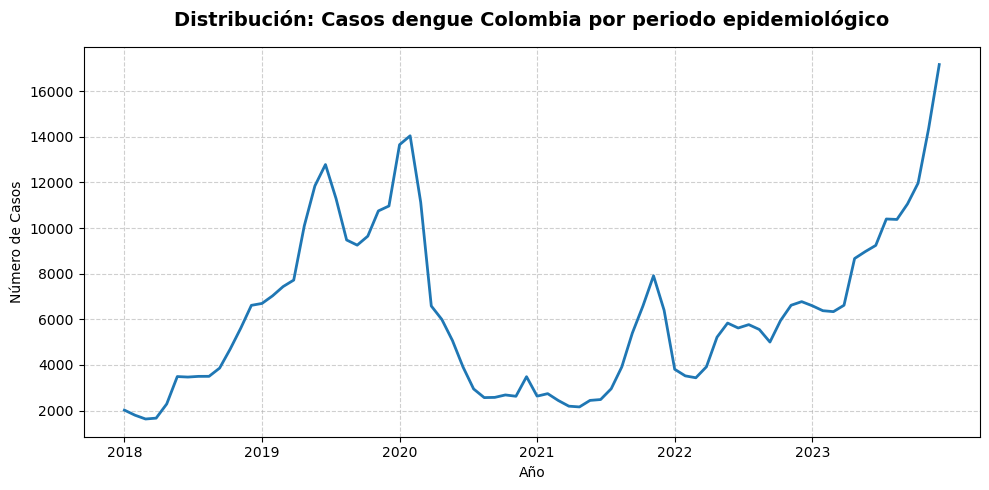

In [10]:
# [Gráfico] Casos por periodo
casos_periodo = data_col.groupby(["año", "periodo"]).size().reset_index(name="casos")
casos_periodo = casos_periodo.sort_values(["año", "periodo"]).reset_index(drop=True)
casos_periodo["index"] = range(len(casos_periodo))

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(casos_periodo["index"], casos_periodo["casos"], linewidth=2)
años_unicos = casos_periodo["año"].unique()
ticks = [casos_periodo[casos_periodo["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title('Distribución: Casos dengue Colombia por periodo epidemiológico',  fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

El gráfico muestra una evolución altamente cíclica del dengue a lo largo del periodo 2018–2023, con oscilaciones marcadas que reflejan los patrones estacionales y multianuales característicos de esta enfermedad. Se observan incrementos progresivos en los primeros meses de cada año, seguidos por descensos posteriores, lo que coincide con las variaciones climáticas que favorecen o limitan la proliferación del Aedes aegypti (particularmente periodos de lluvias y aumentos de temperatura). Dos picos epidémicos sobresalen claramente: uno a finales de 2019 y comienzos de 2020, y otro aún más pronunciado en el segundo semestre de 2023, lo cual confirma que estos años concentraron las mayores intensidades de transmisión.

Tras el pico de 2020, se aprecia un descenso abrupto que marca el inicio de un periodo de baja transmisión entre 2020 y 2021, posiblemente influenciado por restricciones de movilidad, cambios en el acceso a servicios de salud y subregistro asociados a la pandemia por COVID-19. A partir de 2022, el gráfico evidencia un nuevo ciclo de aumento sostenido, con fluctuaciones mensuales pero con tendencia creciente que culmina en una aceleración marcada hacia finales de 2023. Este comportamiento reafirma la naturaleza epidémica del dengue en el país, caracterizada por repuntes cada dos a tres años, lo que resalta la necesidad de mantener una vigilancia continua y estrategias de control oportunas durante los periodos interepidémicos.

## **Atlántico**

In [11]:
# Variables demograficas
print("DEMOGRAFÍA DE LOS REGISTROS")
describir_categorica(data_atl["ciclo_vital"], data_atl)
describir_categorica(data_atl["sexo"], data_atl)
describir_categorica(data_atl["grupo_etnico"], data_atl)
describir_categorica(data_atl["regimen_salud"], data_atl)

DEMOGRAFÍA DE LOS REGISTROS

📌 Variable: ciclo_vital


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
ciclo_vital,,,,,,
Infancia mayor,4424,0.305,4321,103,0.977,0.023
Adolescencia,4327,0.298,4218,109,0.975,0.025
Adulto,3616,0.249,3492,124,0.966,0.034
Infancia menor,1830,0.126,1803,27,0.985,0.015
Adulto mayor,263,0.018,247,16,0.939,0.061
Desconocido,62,0.004,61,1,0.984,0.016



-----------------------------------

📌 Variable: sexo


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
sexo,,,,,,
Masculino,7600,0.523,7398,202,0.973,0.027
Femenino,6922,0.477,6744,178,0.974,0.026



-----------------------------------

📌 Variable: grupo_etnico


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
grupo_etnico,,,,,,
Otro,14232,0.980,13858,374,0.974,0.026
Afrocolombiano,262,0.018,257,5,0.981,0.019
Rom,18,0.001,17,1,0.944,0.056
Indígena,10,0.001,10,0,1.000,0.000



-----------------------------------

📌 Variable: regimen_salud


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
regimen_salud,,,,,,
Subsidiado,7750,0.534,7527,223,0.971,0.029
Contributivo,5784,0.398,5664,120,0.979,0.021
Excepción,531,0.037,522,9,0.983,0.017
No asegurado,340,0.023,314,26,0.924,0.076
Indeterminado,87,0.006,86,1,0.989,0.011
Especial,30,0.002,29,1,0.967,0.033



-----------------------------------


En el departamento del Atlántico, la distribución de casos de dengue según el ciclo vital evidencia una mayor concentración en población infantil y adolescente. La infancia mayor (6–11 años) representa el 30,5% de los casos, seguida muy de cerca por la adolescencia (12–17 años) con el 29,8%; en conjunto, estos grupos aportan más de la mitad de los casos registrados en la región. En tercer lugar se ubica la población adulta (18–59 años) con el 24,9%, mientras que la infancia menor (1–5 años) corresponde al 12,6%. Los casos en adultos mayores (60+ años) representan únicamente el 1,8%, y el 0,4% restante corresponde a registros sin información de edad. Este patrón muestra que, a diferencia del comportamiento nacional donde predomina la afectación en adultos, en el Atlántico el dengue impacta principalmente a personas en edades tempranas.

En cuanto a las características demográficas y de afiliación en salud, el comportamiento es similar al observado a nivel nacional. Los hombres concentran el 52,3% de los casos, manteniendo una ligera predominancia frente a las mujeres. Por otro lado, más de la mitad de los registros (53,4%) corresponde a pacientes afiliados al régimen subsidiado, seguido por el 39,8% perteneciente al régimen contributivo, mientras que el 6,8% restante se agrupa en otras modalidades de afiliación.

In [12]:
# Variables de evento 
print("EVENTO DEL DENGUE EN LOS REGISTROS")
describir_categorica(data_atl["evento"], data_atl)
describir_categorica(data_atl["tipo_caso"], data_atl)
describir_categorica(data_atl["hospitalizado"], data_atl)
describir_categorica(data_atl["desenlace"], data_atl)

EVENTO DEL DENGUE EN LOS REGISTROS

📌 Variable: evento


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
evento,,,,,,
Clasico,14142,0.974,14142,0,1.0,0.0
Grave,380,0.026,0,380,0.0,1.0



-----------------------------------

📌 Variable: tipo_caso


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
tipo_caso,,,,,,
Probable,9886,0.681,9603,283,0.971,0.029
Conf. por laboratorio,4594,0.316,4497,97,0.979,0.021
Conf. por nexo,42,0.003,42,0,1.000,0.000



-----------------------------------

📌 Variable: hospitalizado


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
hospitalizado,,,,,,
Si,9281,0.639,8910,371,0.960,0.040
No,5241,0.361,5232,9,0.998,0.002



-----------------------------------

📌 Variable: desenlace


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
desenlace,,,,,,
Vivo,14515,1.0,14142,373,0.974,0.026
Fallecido,7,0.0,0,7,0.000,1.000



-----------------------------------


En la recopilación de registros solo 380 casos (2.6%) son casos de dengue grave. Más de la mitad de los pacientes (63.9%) fue hospitalizado dada la enfermedad, con solo 7 fallecimientos por dengue grave.

In [13]:
# Variables espaciales
print("OCURRENCIA ESPACIAL DE LOS CASOS")
describir_categorica(data_atl["area"], data_atl)

OCURRENCIA ESPACIAL DE LOS CASOS

📌 Variable: area


,Conteo,Proporción,Clasico,Grave,Prop_Clasico,Prop_Grave
area,,,,,,
Cabecera municipal,13898,0.957,13531,367,0.974,0.026
Centro poblado,553,0.038,540,13,0.976,0.024
Rural disperso,71,0.005,71,0,1.000,0.000



-----------------------------------


In [17]:
# Agrupar casos totales por municipio
tabla_mun = data_atl.groupby("municipio").size().reset_index(name="casos")
pob_total = pob_atl[['MUNICIPIO', 'TOTAL']].copy()
pob_total = pob_total.rename(columns={'MUNICIPIO': 'municipio'})
pob_total = pob_total.rename(columns={'TOTAL': 'poblacion'})
tabla_mun = tabla_mun.merge(pob_total, on='municipio', how='left')
total_casos = tabla_mun['casos'].sum()
tabla_mun['proporcion'] = round(tabla_mun['casos'] / total_casos, 3)
tabla_mun['incidencia'] = round((tabla_mun['casos'] / tabla_mun['poblacion']) * 100000, 2)
tabla_mun = tabla_mun[['municipio', 'casos', 'proporcion', 'poblacion', 
                       'incidencia']]
display(tabla_mun)

,municipio,casos,proporcion,poblacion,incidencia
0,BARANOA,1021,0.070,405184,251.98
1,CAMPO DE LA CRUZ,147,0.010,147981,99.34
2,CANDELARIA,52,0.004,104398,49.81
3,GALAPA,837,0.058,391774,213.64
4,JUAN DE ACOSTA,249,0.017,134313,185.39
5,LURUACO,271,0.019,181093,149.65
6,MALAMBO,1675,0.115,832032,201.31
7,MANATÍ,253,0.017,128844,196.36
8,PALMAR DE VARELA,100,0.007,188904,52.94
9,PIOJÓ,69,0.005,42781,161.29


In [ ]:
# Unir la tabla de incidencia con el mapa por nombre de departamento
mapa_atl = mapa_atl.merge(tabla_mun, on='municipio', how='left')

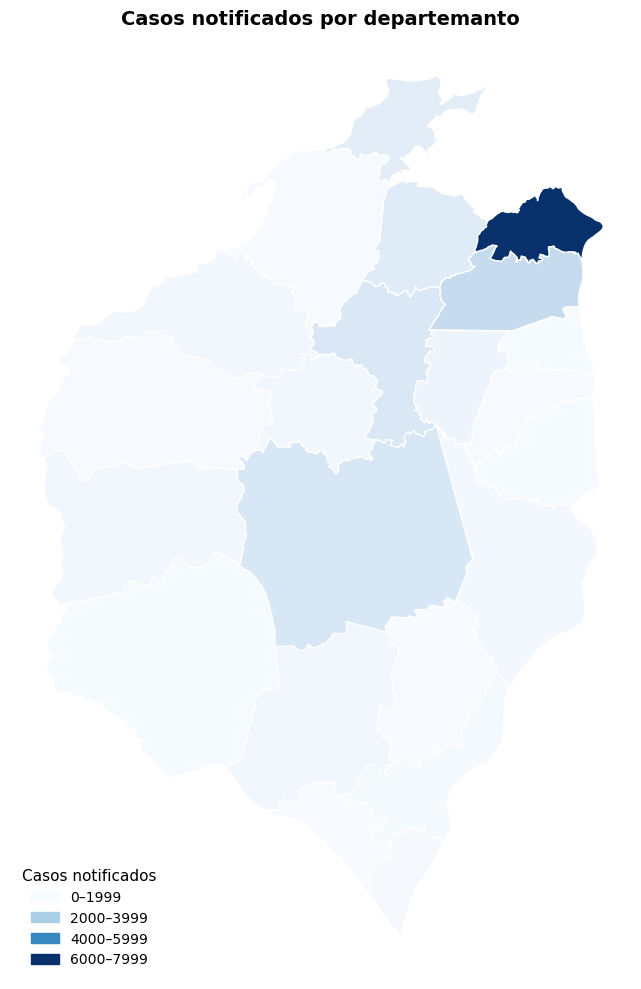

In [33]:
bins = [0, 2000, 4000, 6000, 8000]
cmap = plt.cm.Blues
norm = colors.BoundaryNorm(bins, cmap.N)

# Configurar el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
mapa_atl.plot(column='casos',
              cmap=cmap,
              linewidth=1,
              edgecolor='1',
              legend_kwds={'label': "Casos notificados"},
              ax=ax)
# Crear leyenda personalizada con parches
legend_labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]
legend_colors = [cmap(norm(bins[i])) for i in range(len(bins)-1)]
patches = [mpatches.Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Añadir leyenda al gráfico
ax.legend(handles=patches,
          title="Casos notificados",
          loc='lower left',
          frameon=False,
          fontsize=10,
          title_fontsize=11)

# Estética del mapa
ax.set_title("Casos notificados por departemanto", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

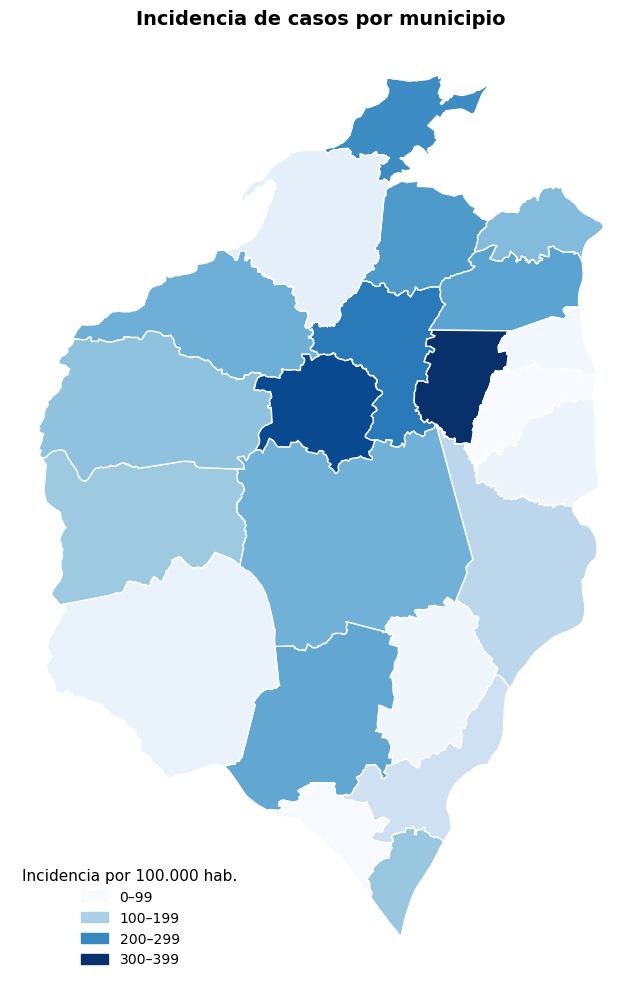

In [29]:
bins = [0, 100, 200, 300, 400]
cmap = plt.cm.Blues
norm = colors.BoundaryNorm(bins, cmap.N)

# Configurar el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
mapa_atl.plot(column='incidencia',
              cmap=cmap,
              linewidth=1,
              edgecolor='1',
              legend_kwds={'label': "Incidencia por 100.000 habitantes"},
              ax=ax)
# Crear leyenda personalizada con parches
legend_labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]
legend_colors = [cmap(norm(bins[i])) for i in range(len(bins)-1)]
patches = [mpatches.Patch(color=legend_colors[i], label=legend_labels[i]) for i in range(len(legend_labels))]

# Añadir leyenda al gráfico
ax.legend(handles=patches,
          title="Incidencia por 100.000 hab.",
          loc='lower left',
          frameon=False,
          fontsize=10,
          title_fontsize=11)

# Estética del mapa
ax.set_title("Incidencia de casos por municipio", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

La distribución municipal de los casos de dengue en el departamento del Atlántico muestra que Soledad concentra la mayor carga epidemiológica, aportando el 46% de todos los registros y acumulando un total de 6.673 casos, una cifra ampliamente superior al resto de municipios. Le siguen Malambo (11,5%), Sabanalarga (7,5%) y Baranoa (7,0%), que representan los otros focos urbanos de mayor magnitud en términos absolutos. En contraste, municipios como Santa Lucía, Santo Tomás, Piojó, Tubará y Candelaria reportan una proporción mucho menor de casos, situándose por debajo del 1% del total, lo que sugiere un impacto más limitado o poblaciones más pequeñas en estos territorios.

Al analizar la incidencia, emergen patrones distintos a los observados en los conteos. Los valores más altos se registran en Polonuevo (33.8 casos por 10,000 hab.), Usiacurí (30.8) y Baranoa (25.2), municipios donde el riesgo relativo de enfermar por dengue es notablemente mayor. Asimismo, Puerto Colombia, Galapa, Malambo y Manatí presentan incidencias elevadas, superiores a 180 casos por 10,000 habitantes. Por el contrario, Sabanagrande, Santa Lucía, Santo Tomás y Candelaria muestran los niveles más bajos de incidencia, inferiores a 50 por 10,000 habitantes. De esta manera, la zona céntrica del departamento es la que mayor incidencia de casos presenta, sumado a la zona metropolitana y costera. Estos contrastes reflejan la coexistencia de zonas de alta transmisión con otras de baja circulación viral dentro del departamento.

OCURRENCIA TEMPORAL DE LOS CASOS


,count
año,
2018,1594
2019,2060
2020,1295
2021,3172
2022,4257
2023,2144


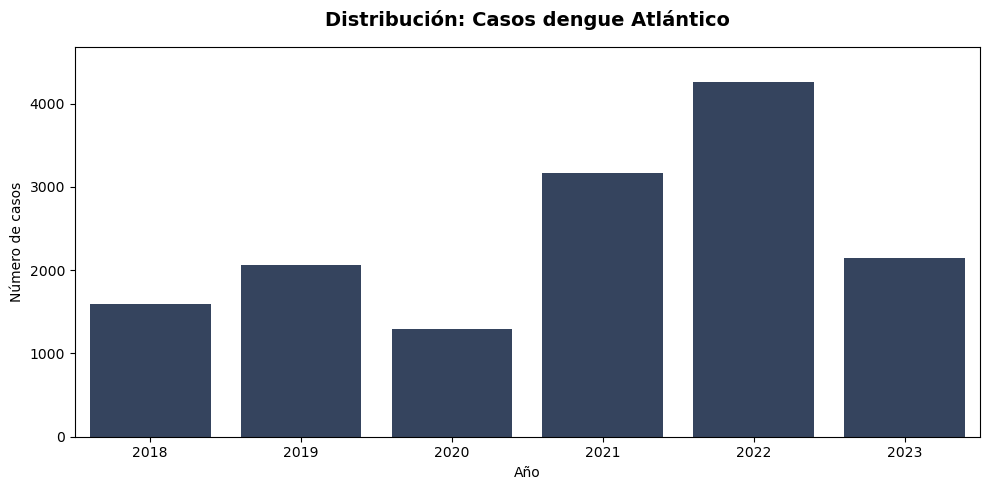

In [15]:
# Variables temporales
print("OCURRENCIA TEMPORAL DE LOS CASOS")
conteo_por_año = data_atl['año'].value_counts(sort=False).sort_index()
display(conteo_por_año.to_frame())

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución: Casos dengue Atlántico', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La ocurrencia temporal de los casos de dengue, muestra un patron de fluctuaciones. En 2021 y 2022, se registraron los picos más altos de casos, con 3,172 y 4,257 notificaciones respectivamente, evidenciando años de alta circulación viral. Estos incrementos contrastan con los descensos observados en 2020 y 2022, cuando los casos disminuyeron a 1,295 y 2,144.

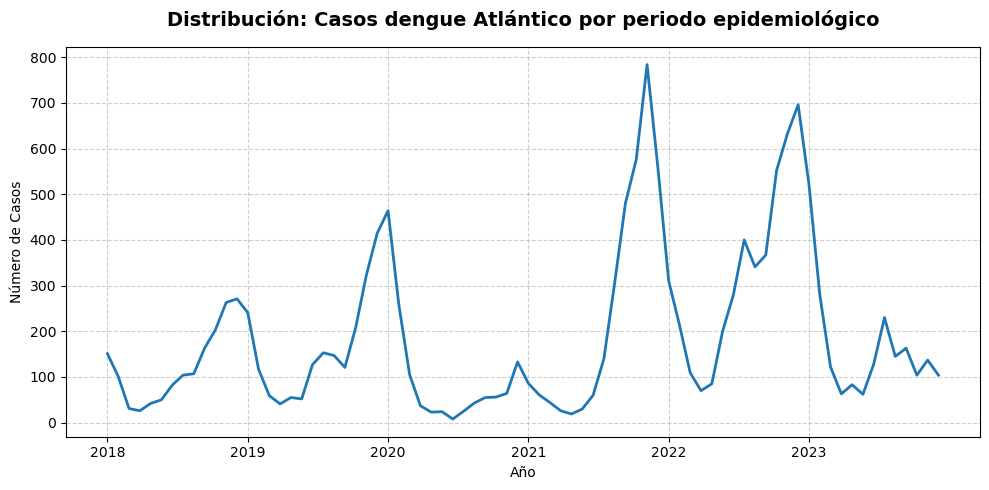

In [16]:
# [Gráfico] Casos por periodo
casos_periodo = data_atl.groupby(["año", "periodo"]).size().reset_index(name="casos")
casos_periodo = casos_periodo.sort_values(["año", "periodo"]).reset_index(drop=True)
casos_periodo["index"] = range(len(casos_periodo))

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(casos_periodo["index"], casos_periodo["casos"], linewidth=2)
años_unicos = casos_periodo["año"].unique()
ticks = [casos_periodo[casos_periodo["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title('Distribución: Casos dengue Atlántico por periodo epidemiológico',  fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

La evolución de los casos de dengue por periodo epidemiológico en el Atlántico evidencia un comportamiento fuertemente estacional, con picos recurrentes. Entre 2018 y 2023 se observan varios repuntes significativos, pero destacan especialmente tres grandes brotes: el primero a finales de 2019 e inicios de 2020, cuando los casos alcanzan valores cercanos a los 450 casos por periodo, el segundo en 2022, donde se registra el pico más alto de toda la serie, superando los 780 casos, por último el registrado en hacia finales del 2023, con alrededor de 700 casos. 

A lo largo de toda la serie es evidente un patrón de crecimientos acelerados seguidos por caídas abruptas. Hacia finales de 2023, los casos vuelven a disminuir y se mantienen alrededor de los 100–150 registros, lo cual sugiere una fase de baja transmisión tras el ciclo epidémico reciente. En conjunto, la serie temporal revela que el dengue en el Atlántico mantiene un comportamiento cíclico, teniendo un comportamiento desendente hacia la primera mitad del año, con un aumento marcado en la segunda mitad. 

## **Variables del entorno**

In [ ]:
clima = pd.read_csv("https://raw.githubusercontent.com/Darally06/ETL_DENGUE/main/DATA/clima_diario.csv")
clima = clima[clima['año'] != 2017]
clima['fecha'] = pd.to_datetime(clima['fecha'])

In [7]:
clima.describe()

,año,fecha,temp_media,humedad,precipitacion
count,50393.000000,50393,50393.000000,50393.000000,50393.000000
mean,2020.499772,2020-12-30 23:59:59.999999744,27.714195,89.302638,5.976514
min,2018.000000,2018-01-01 00:00:00,23.930154,73.644394,0.000000
25%,2019.000000,2019-07-02 00:00:00,27.063160,86.603676,0.250000
50%,2020.000000,2020-12-31 00:00:00,27.679956,89.928444,2.730000
75%,2022.000000,2022-07-02 00:00:00,28.324213,92.377078,8.500000
max,2023.000000,2023-12-31 00:00:00,31.684930,98.449409,108.900002
std,1.707486,NaN,0.939135,3.892999,8.666733


In [23]:
# Agrupar por año y calcular la media de las variables climáticas
media_anual= clima.groupby(['año'])[['temp_media', 'humedad', 'precipitacion']].mean().reset_index()

# Mostrar resultados
display(media_anual)

,año,temp_media,humedad,precipitacion
0,2018,27.700096,89.263676,3.948112
1,2019,27.945027,88.958553,5.525597
2,2020,27.710759,89.167209,6.562609
3,2021,27.519276,89.077765,6.252382
4,2022,27.375048,90.047118,7.857875
5,2023,28.034972,89.301878,5.710901


In [49]:
# Agrupar por año y calcular la media de las variables climáticas
media_mun= clima.groupby(['municipio'])[['temp_media', 'humedad', 'precipitacion']].mean().reset_index()

# Mostrar resultados
display(media_mun)

,municipio,temp_media,humedad,precipitacion
0,BARANOA,27.184574,90.815242,7.870867
1,BARRANQUILLA,27.646830,86.985581,4.732958
2,CAMPO DE LA CRUZ,28.269641,88.759571,5.926869
3,CANDELARIA,27.957802,90.145172,5.926869
4,GALAPA,27.246524,89.470674,4.732958
5,JUAN DE ACOSTA,27.373125,88.797321,5.030954
6,LURUACO,27.455597,89.624173,5.112386
7,MALAMBO,27.623812,89.127638,5.778927
8,MANATÍ,28.361331,87.952611,6.365034
9,PALMAR DE VARELA,27.978848,89.812750,7.870867


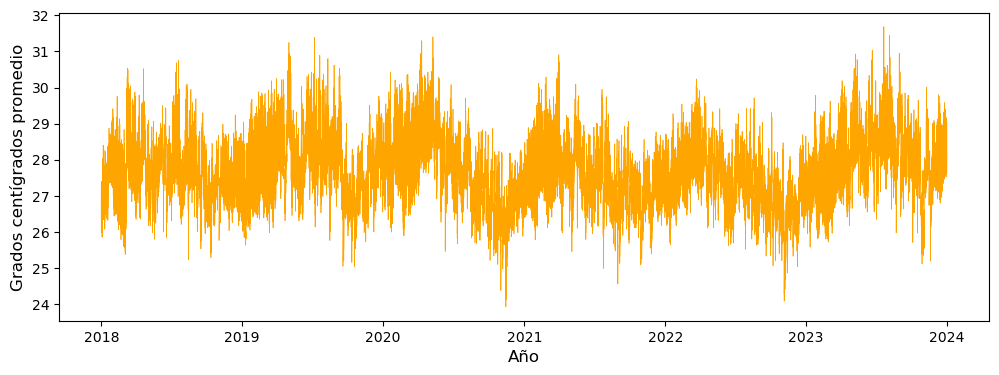

In [11]:
# Temperatura media

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clima['fecha'], clima['temp_media'], linewidth=0.5, label='Temperatura media', color='orange')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Grados centígrados promedio', fontsize=12)
plt.show()

En el periodo estudiado el clima en el departamento del Atlántico puede describirse por tener una temperatura media entre los 25.1°C y 30.2°C, con un promedio de 27.7°($\pm$ 0.9°), con registros máximos de 23.9 a 31.6°C. Es variable, alcanzando las temperaturas más altas hacia la mitad de cada año. La mitad de los registros de temperatura oscilan entre los 27.06°C y 28.32°C. El municipio más caluroso es Manatí con una temperatura media de 28.3°C, mientras que el más fresco es Tubará con 27.1°C. 


Por su parte la humedad relativa, muestra una tendencia cíclica de variabilidad anual, donde hacia el tercer cuarto de cada año se presentan los indices más altos de humedad, con los más bajos en el primer cuarto. 
Varia entre el 77.9% y el 98.4%, alcanzando valores extremos como un mínimo de 73.6%. La distribución de este indicador climático tiene una distribución negativa, con una mediana del 89%. El año con mayor humedad media fue el 2022 con 90.04%, mientras que Ponedera es el municipio con mayor humedad media (91.2%).

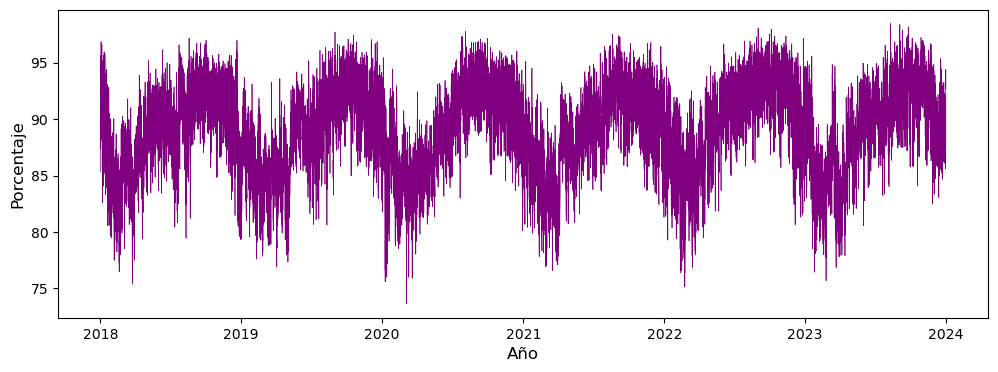

In [ ]:
# Humedad

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clima['fecha'], clima['humedad'], linewidth=0.5, label='Humedad', color='purple')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje', fontsize=12)
plt.show()

In [27]:
print(clima['precipitacion'].describe())
q1 = clima['precipitacion'].quantile(0.25)
q3 = clima['precipitacion'].quantile(0.75)
iqr = q3 - q1

# Bigotes según regla de Tukey
lower_whisker = clima['precipitacion'][clima['precipitacion'] >= (q1 - 1.5 * iqr)].min()
upper_whisker = clima['precipitacion'][clima['precipitacion'] <= (q3 + 1.5 * iqr)].max()

print("Bigote inferior:", lower_whisker)
print("bigsip", upper_whisker)

count    50393.000000
mean         5.976514
std          8.666733
min          0.000000
25%          0.250000
50%          2.730000
75%          8.500000
max        108.900002
Name: precipitacion, dtype: float64
Bigote inferior: 0.0
bigsip 20.87166680230035


Las precipitaciones tienen un comportamiento variable 

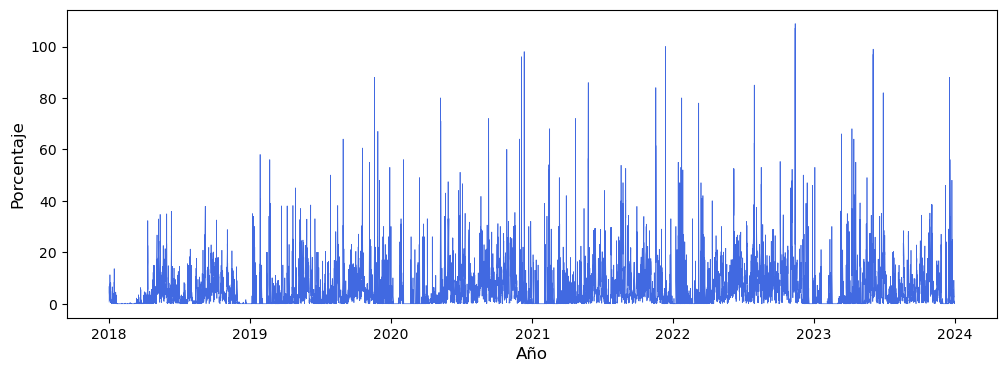

In [26]:
# Humedad

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clima['fecha'], clima['precipitacion'], linewidth=0.5, label='precipitacion', color='royalblue')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje', fontsize=12)
plt.show()